[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/angeld222/CasalsFranco/blob/main/entornos_complejos/notebook_2_diferencias_temporales.ipynb)

# **Métodos de Diferencias Temporales con Blackjack**
**Autores:** Gloria Casals y Ángel Franco

## **Introducción al Entorno y Métodos TD**

En este estudio evaluamos los métodos de **Diferencias Temporales (TD)**: SARSA (On-Policy) y Q-Learning (Off-Policy). A diferencia de Monte Carlo, los algoritmos TD no esperan al final del episodio para aprender, sino que realizan actualizaciones paso a paso utilizando estimaciones previas (bootstrapping).

* **SARSA (On-Policy):** Actualiza el valor de $Q(S_t, A_t)$ utilizando la acción real $A_{t+1}$ que la política actual ($\epsilon$-greedy) tomará en el siguiente estado.
* **Q-Learning (Off-Policy):** Actualiza el valor utilizando la mejor acción posible en el estado $S_{t+1}$, ignorando lo que la política exploratoria vaya a hacer realmente.

In [ ]:
# Clonamos el repositorio
!git clone https://github.com/AngelD222/CasalsFranco.git

Cloning into 'CasalsFranco'...
remote: Enumerating objects: 688, done.
remote: Counting objects: 100% (157/157), done.
remote: Compressing objects: 100% (155/155), done.
remote: Total 688 (delta 48), reused 1 (delta 1), pack-reused 531 (from 2)
Receiving objects: 100% (688/688), 172.28 KiB | 3.31 MiB/s, done.
Resolving deltas: 100% (205/205), done.


In [ ]:
import os
import sys
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

repo_name = 'CasalsFranco/entornos_complejos'

# Añadimos la ruta al sistema
if f'/content/{repo_name}' not in sys.path:
    sys.path.append(f'/content/{repo_name}')

print("Archivos en el directorio:")
!ls /content/{repo_name}

from src.utils.seeder import set_seed, make_env
from src.utils.trainer import train_agent
from src.agents.sarsa import AgentSARSA
from src.agents.q_learning import AgentQLearning
from src.utils.plotter import plot_episode_rewards, plot_episode_lengths, plot_win_rate, plot_multiple_seeds_rewards, moving_average

# Si has guardado el wrapper en utils, descomenta la siguiente línea:
# from src.utils.wrappers import PenalizeBustWrapper

# Wrapper que ya hemos usado en MonteCarlo
class PenalizeBustWrapper(gym.Wrapper):
    def __init__(self, env, bust_penalty=-5.0):
        super().__init__(env)
        self.bust_penalty = bust_penalty

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        if terminated and obs[0] > 21:
            reward = self.bust_penalty
        return obs, reward, terminated, truncated, info

SEMILLA = 2908
set_seed(SEMILLA)

EPISODIOS = 500000
VENTANA = 10000
# En TD tabular usamos una tasa de aprendizaje alpha.
# Usamos un alpha pequeño (0.05) porque Blackjack es muy estocástico y queremos actualizaciones suaves.
hiperparametros_td = {'gamma': 1.0, 'epsilon': 1.0, 'alpha': 0.05}

Archivos en el directorio:
README.md  src
Usando dispositivo: cpu


## **Estudio 1: Entorno con castigo severo**

En este primer experimento analizamos el comportamiento de:
- **SARSA (On-Policy)**
- **Q-Learning (Off-Policy)**

En un entorno de Blackjack modificado donde penalizamos severamente el hecho de pasarse de 21 (bust) con una recompensa de -5.0

En el Blackjack estándar, perder suele tener recompensa -1. Al aumentar el castigo a -5:
- Incrementamos el riesgo de explorar
- Forzamos a los algoritmos a gestionar mejor la exploración
- Hacemos más visible el impacto del tipo de actualización (On-Policy vs Off-Policy)

En ambos alogirmos usaremos la política ϵ-greedy con un decaimiento progresivo de ϵ desde 1.0 hasta 0.01. La diferencia clave entre ellos es:
- **SARSA** actualiza usando la acción real siguiente (incluyendo exploración)
- **Q-Learning** actualiza usando la acción óptima teórica futura.

Esto tendrá impacto en cómo gestionan el riesgo


In [ ]:
print("ENTRENAMIENTO CON CASTIGO DE -5.0")

# 1. Agente SARSA (On-Policy)
env_sarsa = make_env("Blackjack-v1", seed=SEMILLA)
env_sarsa_penalizado = PenalizeBustWrapper(env_sarsa, bust_penalty=-5.0)
agent_sarsa = AgentSARSA(env_sarsa_penalizado, hiperparametros_td)

print("\nEntrenando SARSA (Aprende considerando la exploración)...")
stats_sarsa = train_agent(env_sarsa_penalizado, agent_sarsa, EPISODIOS, initial_eps=1.0, final_eps=0.01, decay_rate=0.0001)

# 2. Agente Q-Learning (Off-Policy)
env_q = make_env("Blackjack-v1", seed=SEMILLA)
env_q_penalizado = PenalizeBustWrapper(env_q, bust_penalty=-5.0)
agent_q = AgentQLearning(env_q_penalizado, hiperparametros_td)

print("\nEntrenando Q-Learning (Aprende asumiendo decisiones óptimas)...")
stats_q = train_agent(env_q_penalizado, agent_q, EPISODIOS, initial_eps=1.0, final_eps=0.01, decay_rate=0.0001)

ENTRENAMIENTO CON CASTIGO DE -5.0

Entrenando SARSA (Aprende considerando la exploración)...


Entrenando agente: 100%|██████████| 500000/500000 [01:32<00:00, 5427.70it/s]



Entrenando Q-Learning (Aprende asumiendo decisiones óptimas)...


Entrenando agente: 100%|██████████| 500000/500000 [01:31<00:00, 5446.28it/s]


### **1. Visualización métricas**

Para reducir el ruido aplicamos una media móvil sobre las recompensas por episodio.

La gráfica nos permite observar:
- Velocidad de convergencia
- Estabilidad del aprendizaje
- Diferencias en rendimiento medio.


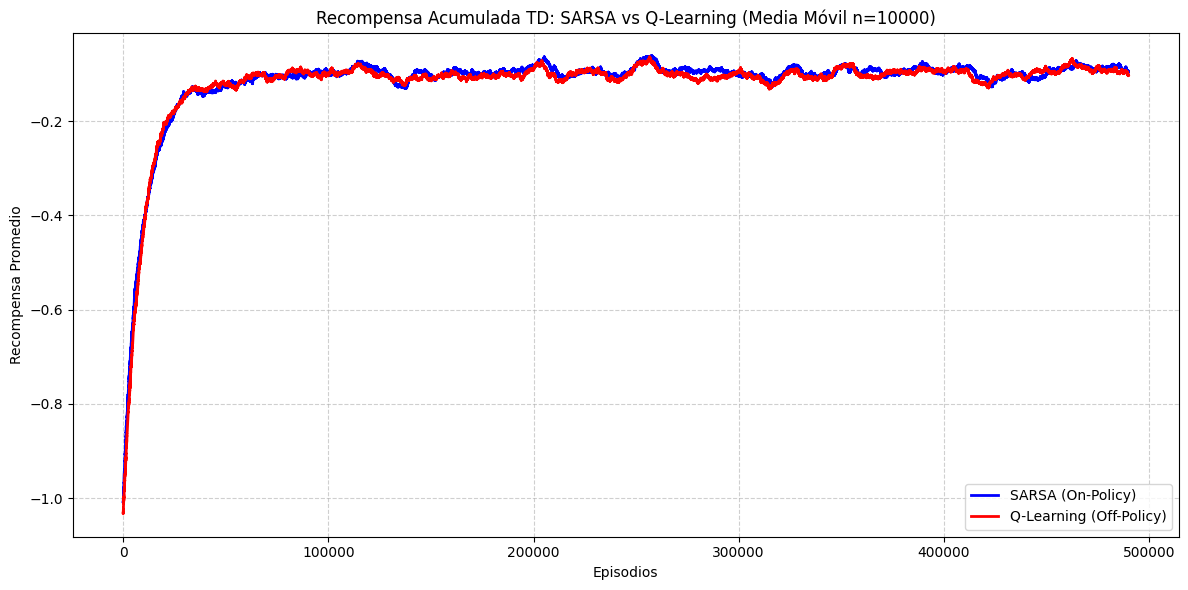

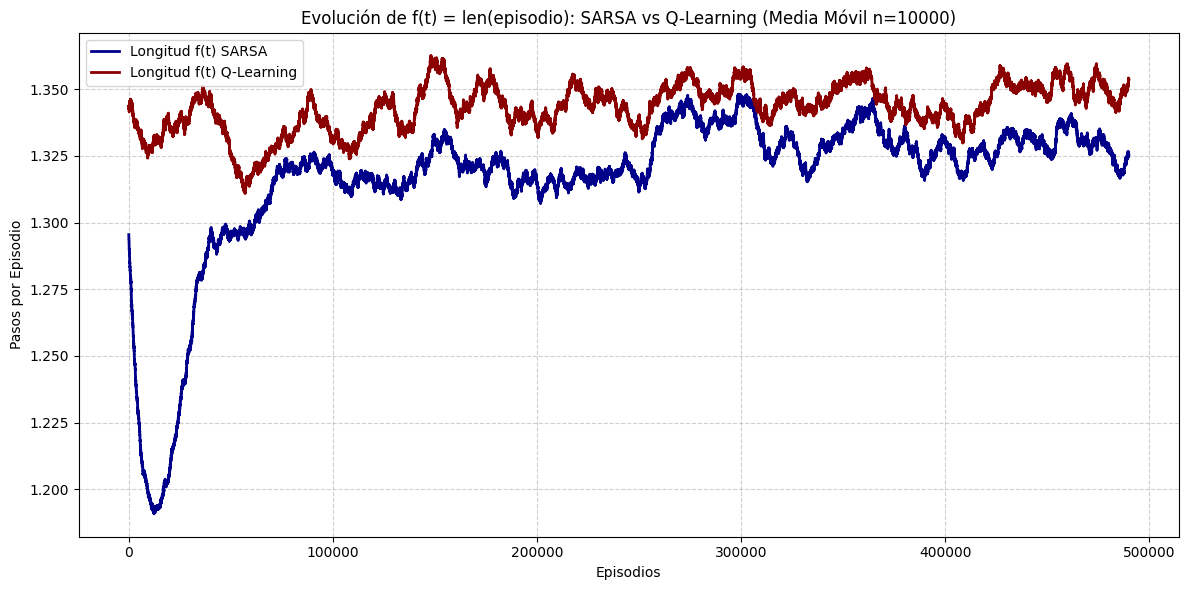

In [ ]:


# Visualización combinada para comparar directamente
recompensas_sarsa = moving_average(stats_sarsa["episode_rewards"], VENTANA)
recompensas_q = moving_average(stats_q["episode_rewards"], VENTANA)

plt.figure(figsize=(12, 6))
plt.plot(recompensas_sarsa, color='blue', linewidth=2, label='SARSA (On-Policy)')
plt.plot(recompensas_q, color='red', linewidth=2, label='Q-Learning (Off-Policy)')
plt.title(f"Recompensa Acumulada TD: SARSA vs Q-Learning (Media Móvil n={VENTANA})")
plt.xlabel("Episodios")
plt.ylabel("Recompensa Promedio")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# También visualizamos f(t) para entender la diferencia en las políticas
longitud_sarsa = moving_average(stats_sarsa["episode_lengths"], VENTANA)
longitud_q = moving_average(stats_q["episode_lengths"], VENTANA)

plt.figure(figsize=(12, 6))
plt.plot(longitud_sarsa, color='darkblue', linewidth=2, label='Longitud f(t) SARSA')
plt.plot(longitud_q, color='darkred', linewidth=2, label='Longitud f(t) Q-Learning')
plt.title(f"Evolución de f(t) = len(episodio): SARSA vs Q-Learning (Media Móvil n={VENTANA})")
plt.xlabel("Episodios")
plt.ylabel("Pasos por Episodio")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **2. Interpretación**
**Evolución inicial del aprendizaje**

En las primeras fases del entrenamiento ambas curvas presentan una alta variabilidad. Esto es esperable porque:
- El valor de ϵ es alto, por lo que predomina la exploración
- Las estimaciones de Q todavía son poco informativas
- El entorno es estocástico (las cartas son aleatorias)

Durante este período, los agentes sufren frecuentes penalizaciones por "bust", lo que se refleja en recompensas medias bajas y oscilaciones pronunciadas.

**Diferencias en la velocidad de convergencia**

A medida que ϵ decrece y aumenta la explotación:
- Q-Learning tiende a mostrar una mejora más rápida en la recompensa media.
- SARSA suele presentar una progresión más gradual.

Esto se explica por la diferencia en sus reglas de actualización.
Como consecuencia, Q-Learning aprende más agresivamente las acciones que parecen óptimas, mientras que SARSA incorpora en sus estimaciones el coste real de la exploración.

**Estabilidad del aprendizaje**

En la fase final del entrenamiento, ambas curvas tienden a estabilizarse. Dado que el entorno de Blackjack es inherentemente aleatorio, las diferencias no suelen ser extremadamente pronunciadas, a diferencia de lo que ocurre en entornos deterministas (estudio en entorno de CliffWalking más adelante en este notebook).

**Conclusiones**

Los resultados muestran que, en un entorno estocástico con penalización severa:
- Q-Learning puede presentar una convergencia más rápido
- SARSA tiende a reflejar un aprendizaje más prudente.
- Las diferencias son sutiles pero coherentes con la distribución teórica

Este estudio confirma que el impacto del tipo de actualización depende fuertemente de la naturaleza del entorno

### **3. Evaluación**

<>:76: SyntaxWarning: invalid escape sequence '\e'
<>:76: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-2111/872159404.py:76: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title('Tasa de Victorias en Evaluación Voraz ($\epsilon=0$)')



--- INICIANDO FASE DE EVALUACIÓN VORAZ (GREEDY) ---
Resultados SARSA tras 100000 partidas: 42.38% Victorias | Recompensa Media: -0.085
Resultados Q-Learning tras 100000 partidas: 42.37% Victorias | Recompensa Media: -0.086


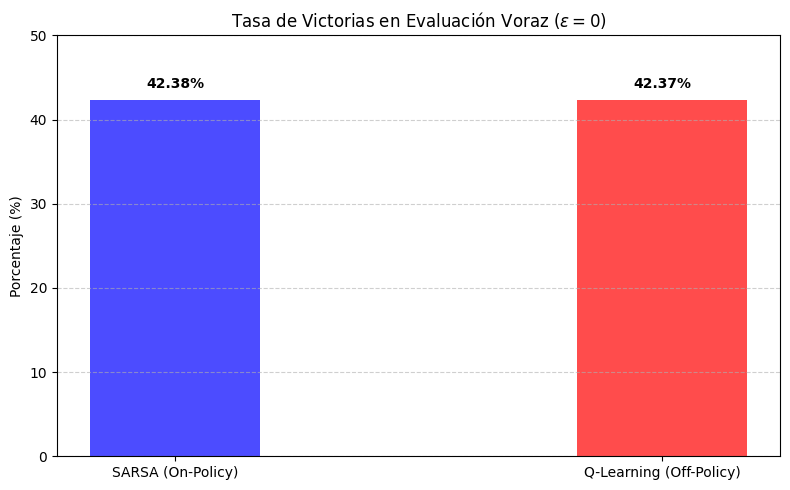

/tmp/ipython-input-2111/872159404.py:109: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


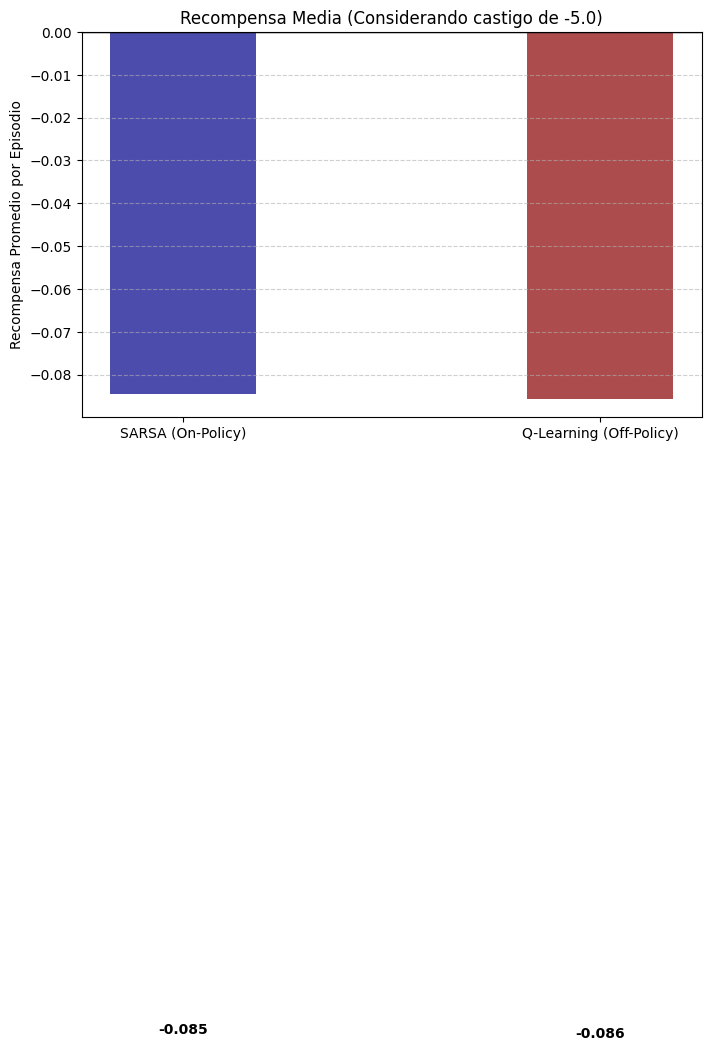

In [ ]:


print("\nFASE DE EVALUACIÓN")

# Parámetros de evaluación
EPISODIOS_EVAL = 100000

def evaluar_agente_td(agente, env, num_episodios):
    """
    Evalúa la tabla Q aprendida apagando la exploración (epsilon = 0.0).
    Extrae tasas de victoria, empate, derrota y métricas promedio.
    """
    agente.epsilon = 0.0  # Apagamos la exploración forzada

    victorias = 0
    empates = 0
    derrotas = 0
    recompensa_total = 0.0
    longitud_total = 0

    for _ in range(num_episodios):
        obs, _ = env.reset()
        done = False
        pasos = 0

        while not done:
            # Comprobamos si el estado existe en la tabla, si no, acción por defecto (0)
            if obs in agente.q_table:
                action = np.argmax(agente.q_table[obs])
            else:
                action = 0

            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            pasos += 1

        recompensa_total += reward
        longitud_total += pasos

        # Clasificamos el resultado (en Blackjack: >0 gana, 0 empata, <0 pierde)
        if reward > 0:
            victorias += 1
        elif reward == 0:
            empates += 1
        else:
            derrotas += 1

    return {
        "win_rate": (victorias / num_episodios) * 100,
        "draw_rate": (empates / num_episodios) * 100,
        "loss_rate": (derrotas / num_episodios) * 100,
        "avg_reward": recompensa_total / num_episodios,
        "avg_length": longitud_total / num_episodios
    }

# Evaluamos ambos agentes en el entorno penalizado.

resultados_sarsa = evaluar_agente_td(agent_sarsa, env_sarsa_penalizado, EPISODIOS_EVAL)
resultados_q = evaluar_agente_td(agent_q, env_q_penalizado, EPISODIOS_EVAL)

print(f"Resultados SARSA tras {EPISODIOS_EVAL} partidas: {resultados_sarsa['win_rate']:.2f}% Victorias | Recompensa Media: {resultados_sarsa['avg_reward']:.3f}")
print(f"Resultados Q-Learning tras {EPISODIOS_EVAL} partidas: {resultados_q['win_rate']:.2f}% Victorias | Recompensa Media: {resultados_q['avg_reward']:.3f}")

# ==========================================
# GRÁFICAS COMPARATIVAS DE EVALUACIÓN
# ==========================================

etiquetas = ['SARSA (On-Policy)', 'Q-Learning (Off-Policy)']
x = np.arange(len(etiquetas))
width = 0.35  # Ancho de las barras

# 1. Gráfica de Tasa de Victorias (%)
fig, ax = plt.subplots(figsize=(8, 5))
barras_win = ax.bar(x, [resultados_sarsa['win_rate'], resultados_q['win_rate']], width, color=['blue', 'red'], alpha=0.7)

ax.set_ylabel('Porcentaje (%)')
ax.set_title('Tasa de Victorias en Evaluación Voraz ($\epsilon=0$)')
ax.set_xticks(x)
ax.set_xticklabels(etiquetas)
ax.set_ylim(0, 50) # El máximo teórico en Blackjack ronda el 42-43%

# Añadir el texto del porcentaje sobre las barras
for bar in barras_win:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 2. Gráfica de Recompensa Promedio (Muestra la aversión al riesgo)
fig, ax = plt.subplots(figsize=(8, 5))
barras_req = ax.bar(x, [resultados_sarsa['avg_reward'], resultados_q['avg_reward']], width, color=['darkblue', 'darkred'], alpha=0.7)

ax.set_ylabel('Recompensa Promedio por Episodio')
ax.set_title('Recompensa Media (Considerando castigo de -5.0)')
ax.set_xticks(x)
ax.set_xticklabels(etiquetas)

for bar in barras_req:
    yval = bar.get_height()
    # Ajustamos la posición del texto dependiendo de si el valor es positivo o negativo
    offset = 0.05 if yval >= 0 else -0.15
    ax.text(bar.get_x() + bar.get_width()/2, yval + offset, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

# Añadimos una línea en el 0 para referencia visual
ax.axhline(0, color='black', linewidth=1)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## **Estudio 2: Análisis de estabilidad**



En el aprendizaje por refuerzo, una única ejecución puede estar sesgada por las condiciones iniciales de la semilla aleatoria, y no podemos basar nuestras conclusiones en un solo ensayo.

Para evaluar la robustez de los algoritmos TD, realizaremos un **análisis de estabilidad frente a distintas semillas aleatorias**, midiendo la varianza del retorno.

**Metodología:**
1. Ejecutaremos el entorno modificado (con `PenalizeBustWrapper`) 5 veces independientes para SARSA y 5 veces para Q-Learning con distintas semillas.
2. Calcularemos el rendimiento promedio sobre estas ejecuciones independientes y su desviación estándar (varianza) en cada episodio.
3. Analizaremos el aprendizaje a corto plazo frente al largo plazo.

**Justificación estadística**

Una sola ejecución puede inducirnos a conclusiones erróneas debido a:
- Inicialización aleatorioa
- Exploración estocástica
- Naturaleza probabilística del entorno.

Por ello ejecutamos múltiples semillas indpenedientes y analizamos:
- Promedio del rendimiento
- Varianza entre ejecuciones

Con esto podemos evaluar la robustez del algoritmo


In [ ]:


# Conjunto de semillas independientes
SEMILLAS_INDEPENDIENTES = [42, 100, 999, 8525, 5555]
EPISODIOS_MULTI = 100000

# Listas para el histórico de recompensas
historico_sarsa_rewards = []
historico_q_rewards = []

# Novedad: Listas para guardar los "cerebros" de los agentes entrenados
agentes_sarsa_guardados = []
agentes_q_guardados = []

print("Iniciando ejecuciones independientes (Entrenamiento):")

for semilla in SEMILLAS_INDEPENDIENTES:
    print(f"\n--- Entrenando con Semilla: {semilla} ---")
    set_seed(semilla)

    # Entorno y Agente SARSA
    env_sarsa_multi = PenalizeBustWrapper(make_env("Blackjack-v1", seed=semilla), bust_penalty=-5.0)
    agent_sarsa_multi = AgentSARSA(env_sarsa_multi, hiperparametros_td)
    stats_sarsa_m = train_agent(env_sarsa_multi, agent_sarsa_multi, EPISODIOS_MULTI, initial_eps=1.0, final_eps=0.01, decay_rate=0.0001)

    historico_sarsa_rewards.append(stats_sarsa_m["episode_rewards"])
    agentes_sarsa_guardados.append(agent_sarsa_multi) # Guardamos el agente

    # Entorno y Agente Q-Learning
    env_q_multi = PenalizeBustWrapper(make_env("Blackjack-v1", seed=semilla), bust_penalty=-5.0)
    agent_q_multi = AgentQLearning(env_q_multi, hiperparametros_td)
    stats_q_m = train_agent(env_q_multi, agent_q_multi, EPISODIOS_MULTI, initial_eps=1.0, final_eps=0.01, decay_rate=0.0001)

    historico_q_rewards.append(stats_q_m["episode_rewards"])
    agentes_q_guardados.append(agent_q_multi) # Guardamos el agente

Iniciando ejecuciones independientes (Entrenamiento):

--- Entrenando con Semilla: 42 ---
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 100000/100000 [00:22<00:00, 4505.25it/s]



--- Entrenando con Semilla: 100 ---
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 100000/100000 [00:22<00:00, 4509.53it/s]



--- Entrenando con Semilla: 999 ---
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 100000/100000 [00:18<00:00, 5389.69it/s]



--- Entrenando con Semilla: 8525 ---
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 100000/100000 [00:18<00:00, 5382.07it/s]



--- Entrenando con Semilla: 5555 ---
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 100000/100000 [00:17<00:00, 5682.41it/s]


### **1. Visualización de curvas suavizadas con varianza**

Para ver el rendimiento promedio en estas ejecuciones independientes y la varianza del retorno, utilizaremos medias móviles y sombrearemos el área correspondiente a una desviación estándar.

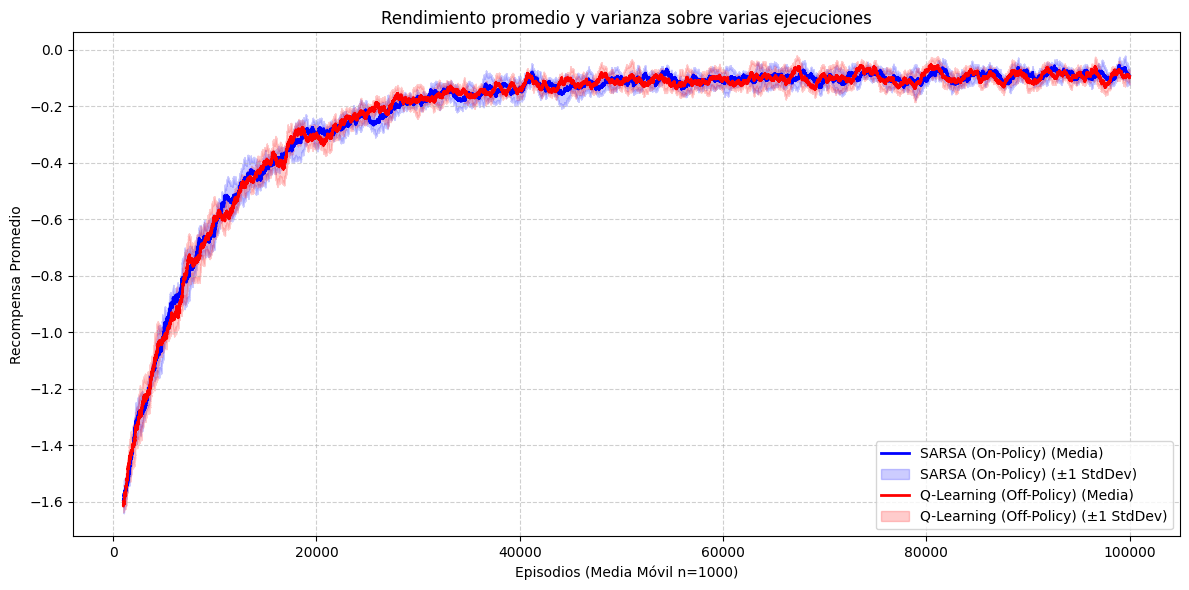

In [ ]:
# Gráfica de entrenamiento
matriz_sarsa = np.array(historico_sarsa_rewards)
matriz_q = np.array(historico_q_rewards)
datos_comparativos = {
    "SARSA (On-Policy)": matriz_sarsa,
    "Q-Learning (Off-Policy)": matriz_q
}
# Dibujamos la gráfica con una ventana de 1000 para quitar el ruido
plot_multiple_seeds_rewards(datos_comparativos, window_size=1000)

### **2. Interpretación**

**Comparación del rendimiento medio**

Las curvas rpomedio de ambos algoritmos presentan una evolución muy similar. Se observa una fase inicial de alta variabilidad seguida de una tendencia creciente hasta estabilizarse en valores cercanos.

No se aprencia una diferencia pronunicada ni sostenida entre las medias finales, lo que indica que, en este entorno de Blackjack con penalización severa, ambos algoritmos convergen a políticas con rendimiento esperado comparable.

**Análisis de la variabilidad**

La banda de desviación estándar es relativamente amplia durante las primeras fases del entrenamiento, reflejando la fuerte influencia de la exploración y la aleatoriedad del entorno.

A medida que avanza el entrenamiento, la variabilidad disminuye progresivamente en ambos métodos, lo que indica que las políticas aprendidas se estabilizan y se vuelven menos sensibles a la semilla inicial.

No se observa la diferentia extrema en la amplitud de las bandas, lo que sugiere que ambos algoritmos presentan un nivel de robustez similar frente a la aleatoriedad inherente al entorno.

**Conlcusiones**

El análisis con múltiples semillas confirma que:
- Las diferencias observadas en una única ejecución pueden deberse al azar.
- En promedio, SARSA y Q-Learning muestran un rendimiento muy similar en este entorno.
- Ambos métodos presentan una convergencia estable tras suficientes episodios.

Por tanto, en entornos altamente estocásticos como Blackjack, la diferencia teórica entre aprendizaje On-Policy y Off-Policy no se traduce en divergencias significativas en rendimiento medio.

### **3. Evaluación**

<>:40: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-2111/4077709984.py:40: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title('Estabilidad de la Política Final (n=5 semillas)\nMedia $\pm$ Desviación Estándar')



FASE DE EVALUACIÓN DE ESTABILIDAD


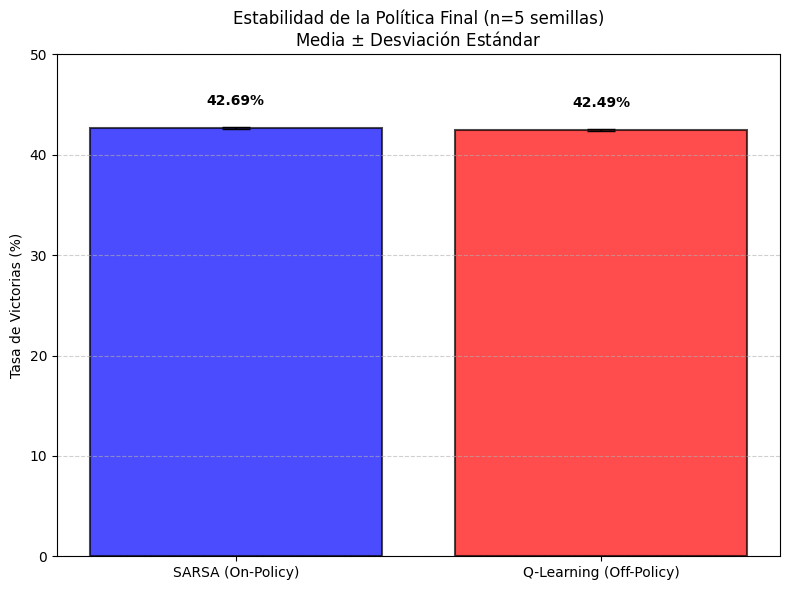

SARSA: 42.69% ± 0.11%
Q-Learning: 42.49% ± 0.10%


In [ ]:
print("\nFASE DE EVALUACIÓN DE ESTABILIDAD")

EPISODIOS_EVAL_MULTI = 50000
resultados_win_sarsa = []
resultados_win_q = []
resultados_req_sarsa = []
resultados_req_q = []

# Evaluamos cada uno de los 5 agentes SARSA y 5 agentes Q-Learning
# (Asumimos que la función evaluar_agente_td está definida como en el experimento anterior)
for i in range(len(SEMILLAS_INDEPENDIENTES)):
    # Usamos un entorno de evaluación limpio (podemos usar una semilla fija para el test)
    env_eval = PenalizeBustWrapper(make_env("Blackjack-v1", seed=2024), bust_penalty=-5.0)

    res_sarsa = evaluar_agente_td(agentes_sarsa_guardados[i], env_eval, EPISODIOS_EVAL_MULTI)
    res_q = evaluar_agente_td(agentes_q_guardados[i], env_eval, EPISODIOS_EVAL_MULTI)

    resultados_win_sarsa.append(res_sarsa['win_rate'])
    resultados_win_q.append(res_q['win_rate'])
    resultados_req_sarsa.append(res_sarsa['avg_reward'])
    resultados_req_q.append(res_q['avg_reward'])

# Cálculos estadísticos (Media y Desviación Estándar)
mean_win_sarsa = np.mean(resultados_win_sarsa)
std_win_sarsa = np.std(resultados_win_sarsa)

mean_win_q = np.mean(resultados_win_q)
std_win_q = np.std(resultados_win_q)

# Gráfico de barras con barras de error
etiquetas = ['SARSA (On-Policy)', 'Q-Learning (Off-Policy)']
medias = [mean_win_sarsa, mean_win_q]
errores = [std_win_sarsa, std_win_q]

fig, ax = plt.subplots(figsize=(8, 6))
barras = ax.bar(etiquetas, medias, yerr=errores, capsize=10,
                color=['blue', 'red'], alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Tasa de Victorias (%)')
ax.set_title('Estabilidad de la Política Final (n=5 semillas)\nMedia $\pm$ Desviación Estándar')
ax.set_ylim(0, 50)

# Añadir el texto de la media exacta
for bar, media in zip(barras, medias):
    ax.text(bar.get_x() + bar.get_width()/2, media + 2,
            f'{media:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"SARSA: {mean_win_sarsa:.2f}% ± {std_win_sarsa:.2f}%")
print(f"Q-Learning: {mean_win_q:.2f}% ± {std_win_q:.2f}%")

## **Estudio 3: MonteCarlo On-Policy vs SARSA**

Utilizando nuestro entorno `PenalizeBustWrapper` (castigo de -5.0 por pasarse de 21) vamos a analizar las diferencias en la eficiencia y el aprendizaje a corto plazo entre los dos métodos tabulares On-Policy.
Ambos algoritmos buscan optimizar la misma política ($\epsilon$-greedy).

Evaluaremos el comportamiento en 10.000 episodios para analizar:
- Velocidad de aprendizaje inicial
- Eficiencia muestral.

Diferencias clave:
- MC actualiza solo al final del episodio
- SARSA actualiza en cada paso (bootstraping)

In [ ]:

from src.agents.monte_carlo import AgentMonteCarloTodasVisitas


EPISODIOS_CORTO_PLAZO = 10000 # Evaluamos el aprendizaje a corto plazo

historico_sarsa_corto = []
historico_mc_corto = []
agentes_sarsa_corto = []
agentes_mc_corto = []

# Hiperparámetros
hiper_comunes = {'gamma': 1.0, 'epsilon': 1.0, 'alpha': 0.05}

print("Iniciando pruebas de aprendizaje a corto plazo sobre múltiples semillas:")

for semilla in SEMILLAS_INDEPENDIENTES:
    set_seed(semilla)

    # 1. Entrenamos SARSA
    env_sarsa = PenalizeBustWrapper(make_env("Blackjack-v1", seed=semilla), bust_penalty=-5.0)
    agent_sarsa = AgentSARSA(env_sarsa, hiper_comunes)
    stats_sarsa = train_agent(env_sarsa, agent_sarsa, EPISODIOS_CORTO_PLAZO, initial_eps=1.0, final_eps=0.01, decay_rate=0.001)
    historico_sarsa_corto.append(stats_sarsa["episode_rewards"])
    agentes_sarsa_corto.append(agent_sarsa) # Guardamos agente SARSA

    # 2. Entrenamos Monte Carlo On-Policy
    # Reiniciamos semilla
    set_seed(semilla)
    env_mc = PenalizeBustWrapper(make_env("Blackjack-v1", seed=semilla), bust_penalty=-5.0)
    agent_mc = AgentMonteCarloTodasVisitas(env_mc, hiper_comunes)
    stats_mc = train_agent(env_mc, agent_mc, EPISODIOS_CORTO_PLAZO, initial_eps=1.0, final_eps=0.01, decay_rate=0.001)
    historico_mc_corto.append(stats_mc["episode_rewards"])


    agentes_mc_corto.append(agent_mc) # Guardamos agente MC

# Preparamos los datos para nuestra función de ploteo
datos_corto_plazo = {
    "SARSA (TD Bootstrapping)": np.array(historico_sarsa_corto),
    "Monte Carlo (Trayectorias Completas)": np.array(historico_mc_corto)
}

Iniciando pruebas de aprendizaje a corto plazo sobre múltiples semillas:
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 10000/10000 [00:01<00:00, 6323.96it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 10000/10000 [00:01<00:00, 6375.86it/s]


Usando dispositivo: cpu


...

Entrenando agente: 100%|██████████| 10000/10000 [00:01<00:00, 6424.02it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 10000/10000 [00:01<00:00, 5159.80it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 10000/10000 [00:01<00:00, 6392.89it/s]


### **1. Visualización**

En esta gráfica se compara la evolución de la recopmensa media durante 10.000 episodios para SARSA y MC con el objetivo  de analizar la eficiencia de aprendizaje en el corto plazo.

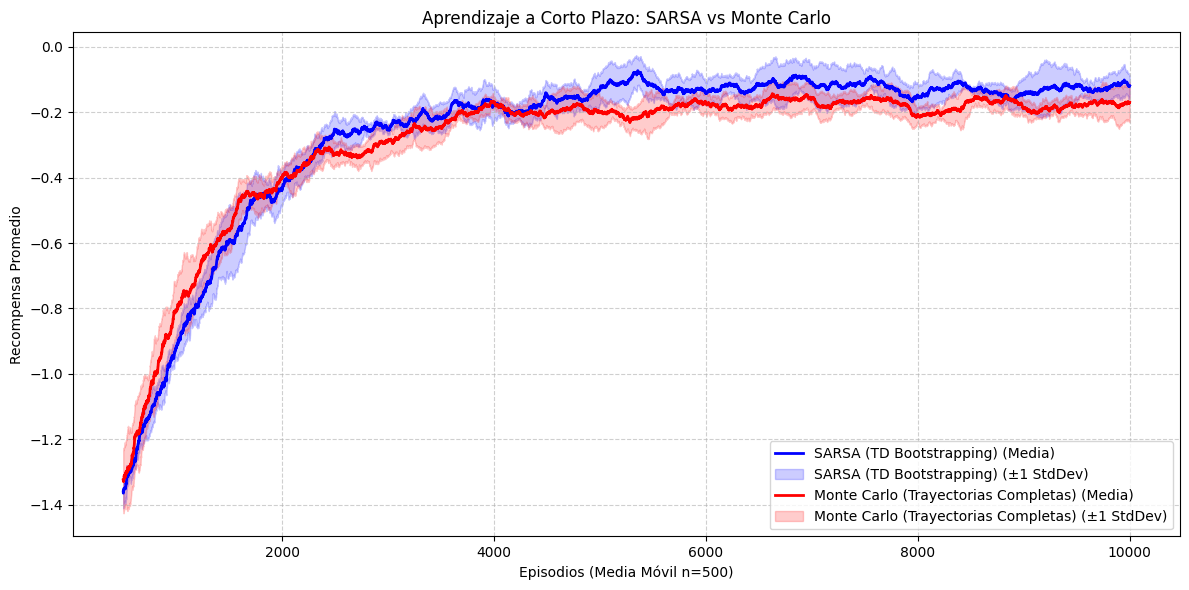

In [ ]:


# Usamos una ventana de 500 para poder ver bien los detalles del corto plazo
plot_multiple_seeds_rewards(datos_corto_plazo, window_size=500, title="Aprendizaje a Corto Plazo: SARSA vs Monte Carlo")

### **2. Interpretación**

**Velocidad de aprendizaje**

Se observa que SARSA mejora su rendimiento más rápidamente en las primeras fases del entrenamiento. Su curva muestra una tendencia ascendente más pronunciada y alcanza antes una zona relativamente estable.

En cambio, MC presenta una mejora más lenta. Durante los primeros episodios su rendimiento es más irregular y tarda más en consolidar una política consistente.

**Estabilidad del entrenamiento**

La curva de MC muestra mayor oscilación en la fase incial. Esto se debe a que este método actualiza los valores únicamente al finalizar cada episodio completo, por lo que necesita acumular experiencias completas para ajustar sus estimaciones.

Por el contrario, SARSA realiza actualizaciones paso a paso (bootstraping), lo que le permite incorporar información de manera más inmediata y estabilizar antes del aprendizaje.

**Conclusión**

Los resultados muestran que, en un horizonte de entrenamiento limitado, SARSA es más eficiente en términos de velocidad de convergencia. MC requiere más episodios para alcanzar un rendimiento similar, lo que evidencia una menor eficiencia muestral en comparación con los métodos de diferencias temporales.

Este expermiento confirma que los métodos TD como SARSA suelen ser más adecuados cuando el número de episodios disponibles es reducido o cuando se busca aprendizaje más rápido en fases tempranas

### **3. Evaluación**

In [ ]:
def plot_blackjack_policy(agente, titulo, usable_ace=False):
    """
    Dibuja un mapa térmico de la política del agente para el Blackjack.
    Eje Y: Suma del jugador (11 a 21)
    Eje X: Carta visible del crupier (1 a 10)
    """
    # Creamos una cuadrícula vacía (11 filas para sumas 11-21, 10 columnas para cartas 1-10)
    policy_grid = np.zeros((11, 10))

    # Rellenamos la cuadrícula consultando la tabla Q del agente
    for player_sum in range(11, 22):
        for dealer_card in range(1, 11):
            state = (player_sum, dealer_card, usable_ace)
            if state in agente.q_table:
                # 0 = Stand (Plantarse), 1 = Hit (Pedir)
                mejor_accion = np.argmax(agente.q_table[state])
                policy_grid[player_sum-11, dealer_card-1] = mejor_accion
            else:
                # Si no visitó el estado, asumimos plantarse por seguridad (o valor nulo)
                policy_grid[player_sum-11, dealer_card-1] = 0

    # Configuración visual
    plt.figure(figsize=(8, 6))

    # Mapa de colores: 0 (Plantarse) en rojo/naranja, 1 (Pedir) en azul/verde
    cmap = sns.color_palette("coolwarm", 2)
    ax = sns.heatmap(policy_grid, cmap=cmap, linewidths=.5, linecolor='lightgray',
                     xticklabels=range(1, 11), yticklabels=range(11, 22),
                     cbar_kws={"ticks": [0.25, 0.75]})

    # Ajustamos la leyenda
    cbar = ax.collections[0].colorbar
    cbar.set_ticklabels(['0: Plantarse (Stand)', '1: Pedir (Hit)'])

    # Títulos y etiquetas
    plt.title(f"{titulo}\n(As Utilizable: {usable_ace})", fontsize=14, pad=15)
    plt.xlabel("Carta visible del Crupier", fontsize=12)
    plt.ylabel("Suma actual del Jugador", fontsize=12)
    plt.gca().invert_yaxis()  # Para que el 21 quede arriba
    plt.tight_layout()
    plt.show()

<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-2111/887551332.py:31: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title('Estabilidad con Aprendizaje Corto (10.000 eps)\nMedia $\pm$ Desviación Estándar')



INICIANDO FASE DE EVALUACIÓN A CORTO PLAZO


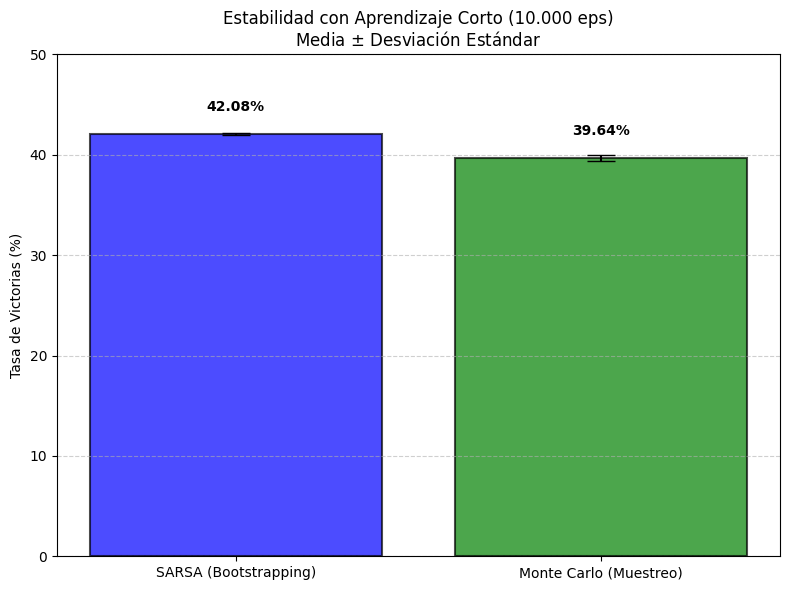

Generando mapas de políticas tempranas (10.000 episodios):


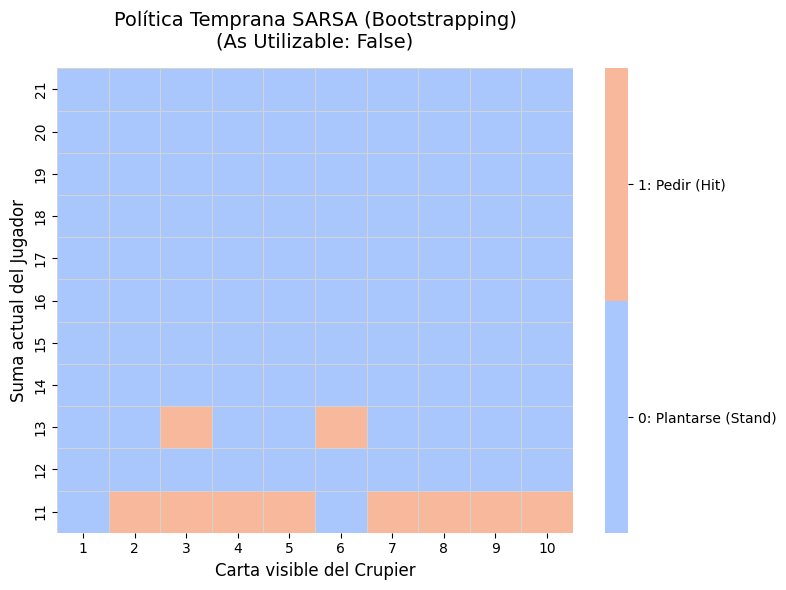

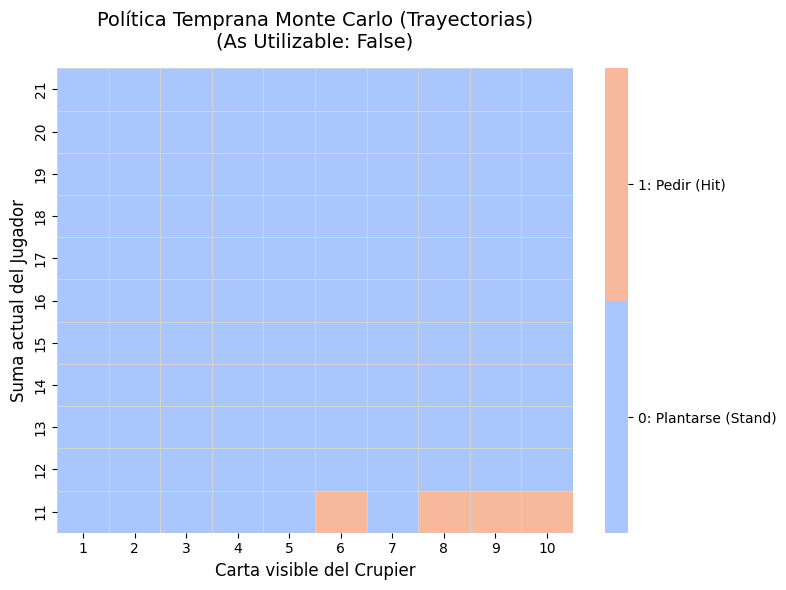

In [ ]:
print("\nINICIANDO FASE DE EVALUACIÓN A CORTO PLAZO")

EPISODIOS_EVAL_CORTO = 50000
resultados_win_sarsa_c = []
resultados_win_mc_c = []

# 1. Evaluamos la estabilidad de los 5 agentes
for i in range(len(SEMILLAS_INDEPENDIENTES)):
    env_eval = PenalizeBustWrapper(make_env("Blackjack-v1", seed=2024), bust_penalty=-5.0)

    res_sarsa_c = evaluar_agente_td(agentes_sarsa_corto[i], env_eval, EPISODIOS_EVAL_CORTO)
    res_mc_c = evaluar_agente_td(agentes_mc_corto[i], env_eval, EPISODIOS_EVAL_CORTO)

    resultados_win_sarsa_c.append(res_sarsa_c['win_rate'])
    resultados_win_mc_c.append(res_mc_c['win_rate'])

# Calculamos estadísticas
mean_sarsa_c = np.mean(resultados_win_sarsa_c)
std_sarsa_c = np.std(resultados_win_sarsa_c)
mean_mc_c = np.mean(resultados_win_mc_c)
std_mc_c = np.std(resultados_win_mc_c)

# Gráfica de barras de error
fig, ax = plt.subplots(figsize=(8, 6))
barras_c = ax.bar(['SARSA (Bootstrapping)', 'Monte Carlo (Muestreo)'],
                  [mean_sarsa_c, mean_mc_c],
                  yerr=[std_sarsa_c, std_mc_c],
                  capsize=10, color=['blue', 'green'], alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Tasa de Victorias (%)')
ax.set_title('Estabilidad con Aprendizaje Corto (10.000 eps)\nMedia $\pm$ Desviación Estándar')
ax.set_ylim(0, 50)

for bar, media in zip(barras_c, [mean_sarsa_c, mean_mc_c]):
    ax.text(bar.get_x() + bar.get_width()/2, media + 2,
            f'{media:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# MAPAS TÉRMICOS

# Cogemos el primer agente de cada lista como representante para la foto
representante_sarsa = agentes_sarsa_corto[0]
representante_mc = agentes_mc_corto[0]

print("Generando mapas de políticas tempranas (10.000 episodios):")
# Usamos la función plot_blackjack_policy del bloque anterior
plot_blackjack_policy(representante_sarsa, "Política Temprana SARSA (Bootstrapping)")
plot_blackjack_policy(representante_mc, "Política Temprana Monte Carlo (Trayectorias)")

## **Conclusiones en el entorno BlackJack**

Si bien Q-Learning y SARSA on algoritmos potentes capaces de resolver el juego, el entorno de Blackjack no permite visualizar su diferencia fundamental: la gestión del riesgo durante la exploración. Ambos agentes aprenderán a jugar "bien", pero para entender realmente la dicotomía entre aprender lo que hago (On-Policy) y aprender lo óptimo (Off-Policy), es necesario un entorno donde los errores de exploración tengan un coste determinista y espacial, como puede ser el entorno CliffWalking. En la siguiente sección usaremos dicho entorno en lugar de Blackjack para reforzar estas conclusiones

# **Métodos de Diferencias Temporales con CliffWalking**

## **Introducción al Entorno**

El entorno CliffWlaking se diseñó específicamente en el libro de Sutton & Barto para demostrar que SARSA y Q-Learning son distintos. Aprovecharemos nuestros experimentos para comprobarlo en nuestro estudio.

El objetivo que se define en este entorno es ir del punto A al punto B evitando un precipicio.

La teoría nos dice que:
* **Q-Learning** (Off-Policy): Aprenderá el camino **óptimo**. Bordeará el precipicio porque asume que en el futuro actuará de forma perfecta (greedy), aunque durante el entrenamiento se caiga a menudo por la exploración.
* **SARSA** (On-Policy): Aprenderá el camino **seguro**. Se alejará del precipicio porque tiene en cuenta que su propia política ($ϵ=0.15$) puede cometer errores aleatorios y empujarlo al vacío.

A diferencia del entorno de Blackjack, este entorno:
- Tiene estructura espacial
- Penalización determinista (-100 al caer por el precipicio)
- Trayectoria claramente óptima.



## **Ejecución en entorno CliffWalking**

La configuración para nuestro experimento es:

- Episodios: 500 por semilla (suficientes dado el tamaño reducido del entorno).

- Exploración (epsilon): Fijo en 0.1 (sin decaimiento, decay_rate = 0.0).

- Tasa de aprendizaje (alpha): 0.5.

Mantener el parámetro de exploración constante a lo largo de todo el entrenamiento es el detalle más importante de este experimento. Si su tendencia fuera a 0, la exploración desaparecería y ambos algoritmos convergerían exactamente a la misma política (el camino óptimo).

In [ ]:

SEMILLAS_INDEPENDIENTES = [42, 100, 999, 8525, 5555]

# Configuración específica para CliffWalking
EPISODIOS_CW = 500
# Importante: Epsilon NO debe decaer a 0 para ver la diferencia de "seguridad"
# Si epsilon es 0, ambos harían lo mismo. Mantenemos 10% de ruido.
hp_cw = {'gamma': 1.0, 'epsilon': 0.1, 'alpha': 0.5}

# Listas para guardar históricos y agentes (multi-semilla)
historico_cw_sarsa = []
historico_cw_q = []
agentes_cw_sarsa = []
agentes_cw_q = []

print("Entrenamiento en CliffWalking sobre múltiples semillas:")

for semilla in SEMILLAS_INDEPENDIENTES:
    print(f"--- Entrenando con Semilla: {semilla} ---")
    set_seed(semilla)

    # 1. SARSA en CliffWalking

    env_cw_sarsa = make_env("CliffWalking-v1", seed=semilla)
    agent_cw_sarsa = AgentSARSA(env_cw_sarsa, hp_cw)
    # decay_rate=0.0 para mantener epsilon constante en 0.1
    stats_cw_sarsa = train_agent(
        env_cw_sarsa,
        agent_cw_sarsa,
        EPISODIOS_CW,
        initial_eps=0.1,
        final_eps=0.1,
        decay_rate=0.0
    )
    historico_cw_sarsa.append(stats_cw_sarsa["episode_rewards"])
    agentes_cw_sarsa.append(agent_cw_sarsa) # Guardamos el agente para evaluación

    # 2. Q-Learning en CliffWalking
    set_seed(semilla) # Reseteamos semilla por consistencia
    env_cw_q = make_env("CliffWalking-v1", seed=semilla)
    agent_cw_q = AgentQLearning(env_cw_q, hp_cw)

    stats_cw_q = train_agent(
        env_cw_q,
        agent_cw_q,
        EPISODIOS_CW,
        initial_eps=0.1,
        final_eps=0.1,
        decay_rate=0.0
    )
    historico_cw_q.append(stats_cw_q["episode_rewards"])
    agentes_cw_q.append(agent_cw_q) # Guardamos el agente para evaluación

# Preparamos los datos para la gráfica multi-semilla
datos_cw = {
    "SARSA (Camino Seguro)": np.array(historico_cw_sarsa),
    "Q-Learning (Camino Óptimo/Arriesgado)": np.array(historico_cw_q)
}

Iniciando entrenamiento en CliffWalking sobre múltiples semillas...
--- Entrenando con Semilla: 42 ---
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 500/500 [00:00<00:00, 805.36it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 500/500 [00:00<00:00, 1062.62it/s]


--- Entrenando con Semilla: 100 ---
Usando dispositivo: cpu


...

Entrenando agente: 100%|██████████| 500/500 [00:00<00:00, 1147.37it/s]


--- Entrenando con Semilla: 5555 ---
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 500/500 [00:00<00:00, 939.67it/s] 


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 500/500 [00:00<00:00, 763.62it/s]


### **1. Visualización**
Graficamos la evolución de la recompensa media por episodio para SARSA y Q-Learning en el entorno de CliffWalking, manteniendo ϵ constante de 0.1 durante el entrenamiento

<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-2111/63814054.py:5: SyntaxWarning: invalid escape sequence '\e'
  title="Entrenamiento CliffWalking con ruido constante ($\epsilon=0.1$)"


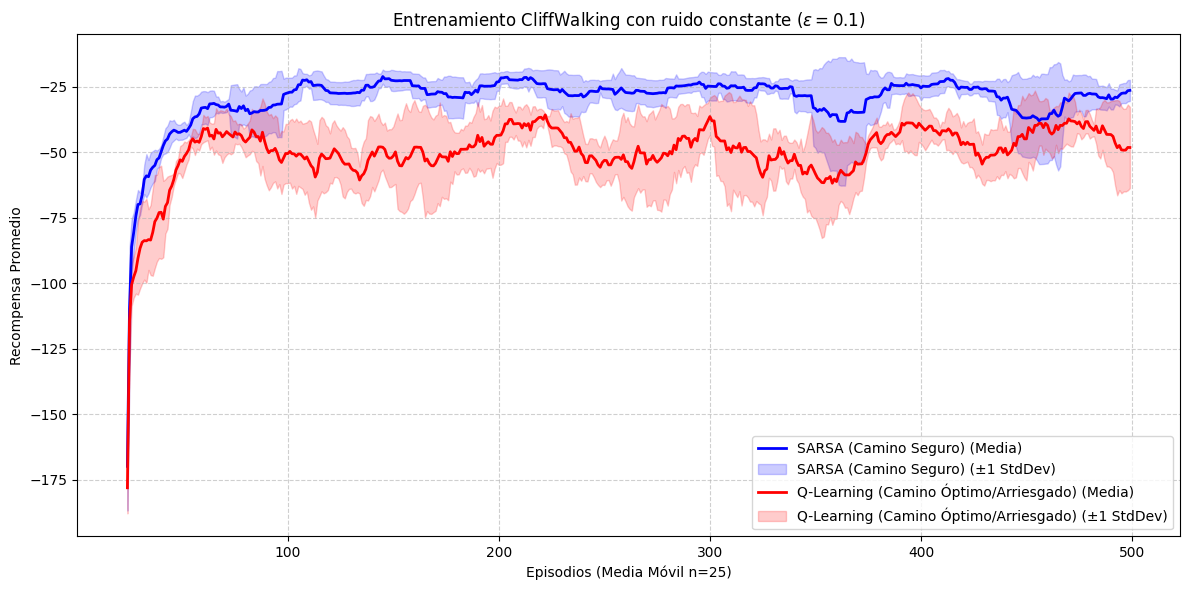

In [ ]:
# Usamos tu función de ploteo múltiple (ventana de 25 está bien para 500 episodios)
plot_multiple_seeds_rewards(
    datos_cw,
    window_size=25,
    title="Entrenamiento CliffWalking con ruido constante ($\epsilon=0.1$)"
)

### **2. Interpretación**

**Comportamiento de Q-Learning**

Se observa que Q-Learning presenta caídas pronunciadas en la recompensa a lo largo del entrenamiento. Estas caídas corresponden a episodios en los que el agente cae en el precipicio y recibe la penalización más grave.

Aunque la política óptima en este entorno es el camino más corto pegado al borde del precipicio, mantener ϵ constante implica que el agente sigue explorando ocasionalmente. Cuando explora en estados cercanos al borde, existe una alta probabilidad de caer, lo que genera estas penalizaciones fuertes y recurrentes.

Esto explica la mayor variabilidad y los picos negativos en su curva.

**Comportamiento de SARSA**

La curva de SARSA es más estable y presenta menos caídas extremas. Esto indica que el agente ha aprendido una poítica más conservadora, alejándose ligeramente del borde del precipicio.

Dado que SARSA actualiza sus valores utilizando la acción realmente ejecutada (incluyendo la exploración), internaliza el riesgo asociado a mantener ϵ constante. Como resultado, prefiere una trayectoria algo más larga pero más segura.

**Comparación**

La gráfica refleja claramente la diferencia conceptual entre ambos enfoques:
- Q-Learning aprende la política óptima teórica (asumiento comportamiento futuro greedy)
- SARSA aprende la política óptima bajo la política ϵ-greedy real.

En un entorno donde los errores tienen un coste muy elevado y la exploración nunca desaparece, SARSA produce un comportamiento más robusto durante el aprendizaje.




### **3. Análisis de la Función de Acción-Valor**

A continuación extraemos el sumatorio promedio de la función de valor
$Q(s,a)$ desglosado por cada acción. Esto nos permite observar cómo la regla de actualización de cada algoritmo (on-policy frente a off-policy) propaga la penalización asociada al precipicio hacia el resto de estados seguros.

No obstante, conviene señalar que el sumatorio de
$Q(s,a)$ sobre todos los estados no constituye una medida especialmente robusta de desempeño, ya que la función Q depende de la política aprendida y de la distribución de estados inducida por dicha política, por lo que comparar directamente estas sumas entre algoritmos no implica necesariamente una comparación directa de rendimiento.

In [ ]:

def obtener_suma_q_por_accion(agente):
    tabla = getattr(agente, 'q_table', None) or getattr(agente, 'Q', None)

    if tabla is None:
        return np.zeros(4) # Devolvemos array de ceros si falla

    if isinstance(tabla, dict):
        valores = list(tabla.values())
        if len(valores) > 0:
            return np.sum(valores, axis=0)
        else:
            return np.zeros(4)
    else:
        return np.sum(tabla, axis=0)

# 1. Obtenemos los arrays de 4 valores para cada uno de los 5 agentes
sumas_sarsa_multi = [obtener_suma_q_por_accion(ag) for ag in agentes_cw_sarsa]
sumas_q_multi = [obtener_suma_q_por_accion(ag) for ag in agentes_cw_q]

# 2. Calculamos la media a través de las 5 semillas (promediamos las filas)
media_acciones_sarsa = np.mean(sumas_sarsa_multi, axis=0)
media_acciones_q = np.mean(sumas_q_multi, axis=0)

# Ajustamos la impresión de numpy para que se vea limpio (sin notación científica)
np.set_printoptions(precision=2, suppress=True)

print("SUMATORIO PROMEDIO DE VALORES Q POR ACCIÓN (n=5 semillas)")
# El orden típico en CliffWalking suele ser: [Arriba, Derecha, Abajo, Izquierda]
print(f"SARSA (On-Policy):      {media_acciones_sarsa}")
print(f"Q-Learning (Off-Policy): {media_acciones_q}")

--- SUMATORIO PROMEDIO DE VALORES Q POR ACCIÓN (n=5 semillas) ---
SARSA (On-Policy):      [ -505.96  -709.26 -1485.5   -651.81]
Q-Learning (Off-Policy): [ -308.9   -377.46 -1344.82  -315.75]


### **4. Evaluación y visualización del camino aprendido**

Como el entorno CliffWalking es determinista, el agente hará el mismo camino siempre. Por lo tanto no necesitamos jugar varios episodios para evaluarlo como hacíamos en Blackjack, con jugar 1 episodio de evaluación por cada uno de los 5 agentes es suficiente para medir su política final.

<>:51: SyntaxWarning: invalid escape sequence '\e'
<>:51: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-2111/61456086.py:51: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title('Rendimiento de la Política Óptima Extraída ($\epsilon=0$)\nMedia $\\pm$ Desviación Estándar (n=5 semillas)')



 FASE DE EVALUACIÓN EN CLIFFWALKING


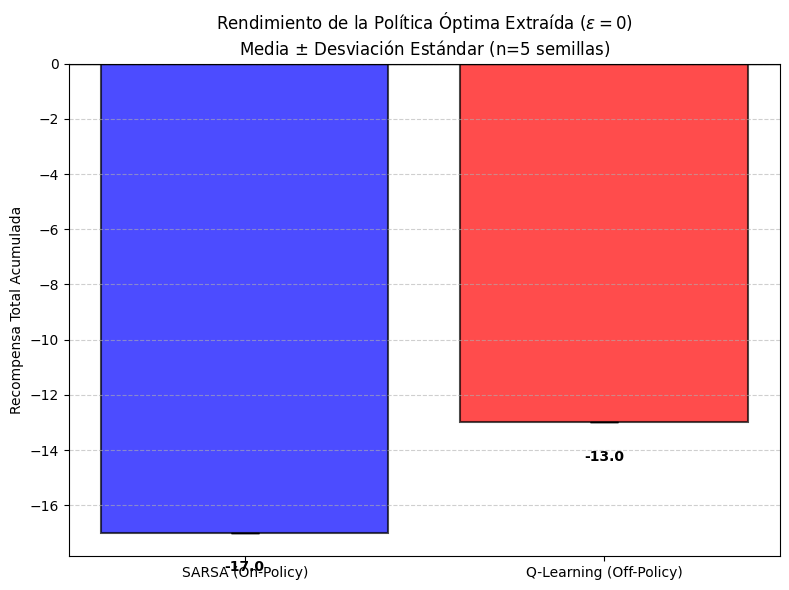

Resultado final SARSA: -17.0 ± 0.00
Resultado final Q-Learning: -13.0 ± 0.00


In [ ]:

print("\n FASE DE EVALUACIÓN EN CLIFFWALKING")

def evaluar_cliff_greedy(agente):
    """
    Ejecuta un episodio determinista voraz (epsilon=0) para extraer
    la recompensa final de la política aprendida.
    """
    env = make_env("CliffWalking-v1", seed=2024)
    obs, _ = env.reset()
    done = False
    total_reward = 0
    pasos = 0

    # Apagamos la exploración
    eps_orig = getattr(agente, 'epsilon', 0.0)
    agente.epsilon = 0.0

    while not done and pasos < 100: # Límite por si el agente se queda en bucle
        tabla = getattr(agente, 'q_table', None) or getattr(agente, 'Q', None)
        action = np.argmax(tabla[obs])

        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
        pasos += 1

    # Restauramos epsilon
    agente.epsilon = eps_orig

    return total_reward

# 1. Evaluamos a los 5 agentes SARSA y los 5 Q-Learning
recompensas_sarsa_eval = [evaluar_cliff_greedy(ag) for ag in agentes_cw_sarsa]
recompensas_q_eval = [evaluar_cliff_greedy(ag) for ag in agentes_cw_q]

# 2. Calculamos estadísticas (Media y Desviación Estándar)
mean_req_sarsa = np.mean(recompensas_sarsa_eval)
std_req_sarsa = np.std(recompensas_sarsa_eval)

mean_req_q = np.mean(recompensas_q_eval)
std_req_q = np.std(recompensas_q_eval)

# 3. Gráfica Comparativa
fig, ax = plt.subplots(figsize=(8, 6))
barras = ax.bar(['SARSA (On-Policy)', 'Q-Learning (Off-Policy)'],
                [mean_req_sarsa, mean_req_q],
                yerr=[std_req_sarsa, std_req_q],
                capsize=10, color=['blue', 'red'], alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Recompensa Total Acumulada')
ax.set_title('Rendimiento de la Política Óptima Extraída ($\epsilon=0$)\nMedia $\\pm$ Desviación Estándar (n=5 semillas)')

# Añadimos los valores en texto (ajustamos posición porque los números son negativos)
for bar, media in zip(barras, [mean_req_sarsa, mean_req_q]):
    ax.text(bar.get_x() + bar.get_width()/2, media - 1,
            f'{media:.1f}', ha='center', va='top', fontweight='bold')

plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Resultado final SARSA: {mean_req_sarsa:.1f} ± {std_req_sarsa:.2f}")
print(f"Resultado final Q-Learning: {mean_req_q:.1f} ± {std_req_q:.2f}")

**Conclusión**

El experimento en este entorno determinista evidencia con claridad la diferencia entre aprendizaje on-policy y off-policy. Mientras Q-learning aprende la política óptima —correspondiente al camino más corto pero arriesgado—, SARSA converge hacia una política más conservadora y estable, al tener en cuenta el efecto de la exploración en sus actualizaciones. Como consecuencia, en evaluación SARSA obtiene un retorno acumulado inferior (más negativo) al de Q-learning, al priorizar trayectorias más seguras pero más largas.

In [ ]:
def imprimir_camino_cliff(agente, titulo=""):
    """
    Imprime una representación visual del camino aprendido.
    C = Cliff (Precipicio), G = Goal (Meta), S = Start, . = Camino seguro, X = Paso del agente
    """
    # Usamos una semilla fija de evaluación para que el entorno sea determinista
    env = make_env("CliffWalking-v1", seed=2024)
    obs, _ = env.reset()

    # Grid de 4x12 típico de CliffWalking
    grid = [['.' for _ in range(12)] for _ in range(4)]
    # Marcamos el precipicio y meta
    for i in range(1, 11):
        grid[3][i] = 'C'
    grid[3][0] = 'S'
    grid[3][11] = 'G'

    terminated = False
    truncated = False
    steps = 0
    total_reward = 0

    # Guardamos el epsilon original y lo forzamos a 0 (Explotación pura)
    agente_epsilon_orig = getattr(agente, 'epsilon', 0.0)
    agente.epsilon = 0.0

    current_obs = obs
    r, c = current_obs // 12, current_obs % 12
    grid[r][c] = 'S'

    # Ampliamos a 30 pasos porque la ruta segura de SARSA es más larga
    while not (terminated or truncated) and steps < 30:
        # Acción estrictamente voraz
        tabla = getattr(agente, 'q_table', None) or getattr(agente, 'Q', None)
        action = np.argmax(tabla[current_obs])

        next_obs, reward, terminated, truncated, _ = env.step(action)

        # Marcar camino
        r, c = next_obs // 12, next_obs % 12
        if grid[r][c] not in ['G', 'C', 'S']:
            grid[r][c] = 'X' # X marca el paso

        total_reward += reward
        current_obs = next_obs
        steps += 1

    # Restaurar epsilon
    agente.epsilon = agente_epsilon_orig

    # Imprimir Grid
    print(f"--- {titulo} ---")
    print(f"Pasos: {steps} | Recompensa Total: {total_reward}")
    for row in grid:
        print(" ".join(row))
    print("\n")

# Evaluamos la política aprendida usando el primer agente de nuestras listas (semilla 1)
print("Visualizando las rutas finales aprendidas (Evaluación Greedy con $\epsilon=0$):\n")

imprimir_camino_cliff(agentes_cw_sarsa[0], titulo="Ruta de SARSA (On-Policy)")
imprimir_camino_cliff(agentes_cw_q[0], titulo="Ruta de Q-Learning (Off-Policy)")

Visualizando las rutas finales aprendidas (Evaluación Greedy con $\epsilon=0$):

--- Ruta de SARSA (On-Policy) ---
Pasos: 17 | Recompensa Total: -17
. X X X X X X X X X X .
X X . . . . . . . . X X
X . . . . . . . . . . X
S C C C C C C C C C C G


--- Ruta de Q-Learning (Off-Policy) ---
Pasos: 13 | Recompensa Total: -13
. . . . . . . . . . . .
. . . . . . . . . . . .
X X X X X X X X X X X X
S C C C C C C C C C C G




<>:59: SyntaxWarning: invalid escape sequence '\e'
<>:59: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-2111/1207040298.py:59: SyntaxWarning: invalid escape sequence '\e'
  print("Visualizando las rutas finales aprendidas (Evaluación Greedy con $\epsilon=0$):\n")


### **5. Interpretación del camino**
Al observar la trayectoria greedy final de cada agente se aprecia una diferencia clara en la estrategia aprendida.

Q-Learning aprende el camino más corto hacia la meta, avanzando pegado al precipicio. Esta es la trayectoria óptima en términos de pasos, pero resulta arriesgada cuando ϵ se mantiene distinto de cero, ya que cualquier acción exploratoria puede provocar una caída y una penalización elevada.

Por el contrario, SARSA aprende un camino ligeramente más alejado del borde. Aunque puede implicar algún paso adicional, reduce el riesgo de caer debido a la exploración.

Esta diferencia visual refleja la distinción conceptual entre ambos métodos: Q-Learning optimiza la política teórica óptima, mientras que SARSA aprende una política más segura bajo la exploración real del agente.

# **Conclusiones del Estudio**

A lo largo de este notebook se ha analizado el comportamiento de distintos algoritmos de aprendizaje por refuerzo —Monte Carlo, SARSA y Q-Learning— en entornos con diferentes características y niveles de riesgo.

En el entorno de Blackjack con penalización severa, se observa que tanto SARSA como Q-Learning convergen a rendimientos similares. Las diferencias entre aprendizaje On-Policy y Off-Policy son relativamente sutiles debido a la alta estocasticidad del entorno. El análisis con múltiples semillas confirma que ambos métodos presentan un comportamiento robusto y comparable en términos de recompensa media.

En el estudio de corto plazo, la comparación entre Monte Carlo y SARSA muestra que los métodos de diferencias temporales son más eficientes en términos de velocidad de aprendizaje. SARSA, al actualizar paso a paso mediante bootstrapping, alcanza antes un rendimiento estable, mientras que Monte Carlo requiere más episodios para consolidar una política eficaz.

Finalmente, el entorno CliffWalking, al ser un entorno determinista, permite visualizar de forma clara la diferencia conceptual entre SARSA y Q-Learning. Mientras Q-Learning aprende el camino óptimo teórico (más corto pero arriesgado), SARSA aprende una trayectoria más segura cuando la exploración se mantiene constante. La diferencia no solo se refleja en las curvas de recompensa, sino también en el camino final aprendido por cada agente.

En conjunto, los experimentos muestran que la elección entre métodos On-Policy y Off-Policy no depende únicamente del rendimiento final, sino también del contexto del problema, del coste asociado a la exploración y del horizonte temporal disponible para el aprendizaje. La naturaleza del entorno y el riesgo inherente a las decisiones influyen de manera decisiva en el comportamiento de los algoritmos.